In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 0. Cargar Datos

In [16]:
path_ventas = "datos/BD2526_oct_mar_ventasxfacturas(con_zonas).csv"
ventas = pd.read_csv(path_ventas)
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_3269/3380775179.py:2: DtypeWarning: Columns (0: Cod Canal Comercial) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [17]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Kilos Nc', 'Monto Nc',
       'Factura Venta', 'Factura Kilos', 'Kilo Real', 'Monto Real', 'Precio',
       'Archivo', 'Hoja', 'Zona'],
      dtype='str')

In [18]:
path_elasticidades = "datos/elasticidades_sku_2526.csv"
elasticidades = pd.read_csv(path_elasticidades)
elasticidades.head()

,Cod SKU,Nombre SKU,N Transacciones,N Clientes,gral_baseline_elasticidad,gral_baseline_se,gral_baseline_pvalor,gral_baseline_r2,gral_baseline_n,gral_baseline_ic95_inf,...,SUR_3_semanal_fe_ic95_inf,SUR_3_semanal_fe_ic95_sup,SUR_3_Ingreso,modelo_sugerido,NORTE_1_modelo_sugerido,NORTE_2_modelo_sugerido,SANTIAGO_modelo_sugerido,SUR_1_modelo_sugerido,SUR_2_modelo_sugerido,SUR_3_modelo_sugerido
0,1020,VIENESA TRADICIONAL 20X250 GR SJ,210197,27662,-1.175533,0.011253,0.0,0.049358,210197.0,-1.197588,...,-0.683748,-0.430678,264526904.0,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE
1,3456,"SALAME LAMINADO 1,6 KG LP",129278,17785,-4.063798,0.029977,0.0,0.124464,129278.0,-4.122553,...,-1.023584,-0.416430,234959435.0,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE
2,6770,QUESO GAUDA LAMINADO 1KG.LOS NOGALES,91766,11387,-4.048486,0.034655,0.0,0.129470,91766.0,-4.116409,...,-1.793636,-1.417501,387786716.0,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE
3,1032,VIENESA TRADICIONAL 8X1 KG SJ,88839,11969,-1.281279,0.022219,0.0,0.036082,88839.0,-1.324828,...,-1.237127,-0.749018,347076498.0,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE
4,3239,JAMON CENTENARIO COLONIAL MINI PZA LP,97470,14064,-1.670464,0.021443,0.0,0.058617,97470.0,-1.712492,...,-1.242821,-0.800389,187455228.0,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE,Panel Semanal FE


In [19]:
elasticidades.columns

Index(['Cod SKU', 'Nombre SKU', 'N Transacciones', 'N Clientes',
       'gral_baseline_elasticidad', 'gral_baseline_se', 'gral_baseline_pvalor',
       'gral_baseline_r2', 'gral_baseline_n', 'gral_baseline_ic95_inf',
       ...
       'SUR_3_semanal_fe_ic95_inf', 'SUR_3_semanal_fe_ic95_sup',
       'SUR_3_Ingreso', 'modelo_sugerido', 'NORTE_1_modelo_sugerido',
       'NORTE_2_modelo_sugerido', 'SANTIAGO_modelo_sugerido',
       'SUR_1_modelo_sugerido', 'SUR_2_modelo_sugerido',
       'SUR_3_modelo_sugerido'],
      dtype='str', length=196)

In [20]:
path_costos = "datos/Costos Directos Marzo.xlsx"
costos = pd.read_excel(path_costos)
costos.head()

,SKU,Descripción,Familia,Kilos Finales CB,Kilos Finales MY,Kilos Finales HR,Kilos Totales,Facturación CB,Facturación MY,Facturación HR,...,Frío Externo HR,Frío Externo Total,Distribución Fijo CB,Distribución Fijo MY,Distribución Fijo HR,Distribución Fijo Total,Costo Producción CB,Costo Producción MY,Costo Producción HR,Costo Producción TOTAL
0,20,ARROLLADO LOMO CON AJI SJ,ARROLLADOS,24715.413,3536.964,457.532,28709.909,117774893,16794721,2225843,...,7341.954494,4.607040e+05,1.266516e+06,1.812480e+05,23445.749686,1.471209e+06,4.480289e+07,6.411634e+06,8.293915e+05,5.204391e+07
1,27,ARROLLADO LOMO SIN AJI SJ,ARROLLADOS,2342.319,174.389,82.125,2598.833,11385036,808507,403481,...,1317.848834,4.170312e+04,1.200297e+05,8.936382e+03,4208.409888,1.331745e+05,3.766568e+06,2.804264e+05,1.320612e+05,4.179056e+06
2,30,ARROLLADO HUASO CON AJI SJ,ARROLLADOS,14366.108,7058.506,151.473,21576.087,70060552,33947983,723044,...,2430.666867,3.462286e+05,7.361762e+05,3.617058e+05,7762.075750,1.105644e+06,3.238481e+07,1.591164e+07,3.414581e+05,4.863791e+07
3,102,ARROLLADO LOMO CON AJI 12x150 GR SJ,ARROLLADOS,4766.550,701.700,97.200,5565.450,26749061,3723999,618487,...,1559.755333,8.930803e+04,2.442569e+05,3.595788e+04,4980.912525,2.851957e+05,1.044027e+07,1.536948e+06,2.128992e+05,1.219012e+07
4,210,FIAMBRE SANDWICH SJ,FIAMBRES,69682.135,30923.507,14657.130,115262.772,237165490,95180369,47725593,...,299281.198913,2.353529e+06,3.570788e+06,1.584643e+06,751089.325119,5.906520e+06,7.747349e+07,3.438115e+07,1.629598e+07,1.281506e+08


In [21]:
costos.columns

Index(['SKU', 'Descripción', 'Familia', 'Kilos Finales CB', 'Kilos Finales MY',
       'Kilos Finales HR', 'Kilos Totales', 'Facturación CB', 'Facturación MY',
       'Facturación HR', 'Facturación Total', 'Aporte CB', 'Aporte MY',
       'Aporte HR', 'Aporte Total', 'Costo CB', 'Costo MY', 'Costo HR',
       'Costo Total', 'Frío Externo CB', 'Frío Externo MY', 'Frío Externo HR',
       'Frío Externo Total', 'Distribución Fijo CB', 'Distribución Fijo MY',
       'Distribución Fijo HR', 'Distribución Fijo Total',
       'Costo Producción CB', 'Costo Producción MY', 'Costo Producción HR',
       'Costo Producción TOTAL'],
      dtype='str')

# 1. Elegir SKU a analizar

In [35]:
elasticidades["gral_semanal_fe_menor_a_1"] = elasticidades["gral_semanal_fe_elasticidad"] < 0#-1

elasticidades["gral_semanal_fe_menor_a_1"].sum()

np.int64(166)

In [23]:
producto_mas_inelastico = elasticidades.sort_values("gral_semanal_fe_elasticidad", ascending=True).iloc[4]
SKU = producto_mas_inelastico["Cod SKU"]
print(SKU)

282


# 2. Análisis

In [24]:
# Agrupar ventas por semana y armar tabla con semana, sku, cantidad vendida, precio promedio
ventas_semanales = (
    ventas.assign(
        semana=pd.to_datetime(ventas["Fecha Factura"], format="%Y%m%d").dt.to_period("W").dt.start_time
    )
    .groupby(["semana", "Cod SKU"], as_index=False)
    .agg(
        cantidad_vendida=("Kilo Real", "sum"),
        monto_vendido=("Monto Real", "sum"),
    )
)

ventas_semanales["precio_promedio"] = np.where(
    ventas_semanales["cantidad_vendida"] > 0,
    ventas_semanales["monto_vendido"] / ventas_semanales["cantidad_vendida"],
    np.nan,
)

ventas_semanales = ventas_semanales[["semana", "Cod SKU", "cantidad_vendida", "precio_promedio"]]
ventas_semanales.head()


,semana,Cod SKU,cantidad_vendida,precio_promedio
0,2025-09-29,20,4001.284,4853.535015
1,2025-09-29,27,533.292,3827.449127
2,2025-09-29,30,2454.733,4837.983194
3,2025-09-29,102,694.650,5566.177212
4,2025-09-29,151,2154.000,3584.112349


In [25]:
COSTOS_DIRECTOS_TOTALES = costos[costos["SKU"]==SKU]["Costo Producción TOTAL"].values[0]
KILOS_TOTALES = costos[costos["SKU"]==SKU]["Kilos Totales"].values[0]
COSTO_DIRECTO_POR_KILO = COSTOS_DIRECTOS_TOTALES / KILOS_TOTALES if KILOS_TOTALES > 0 else 0

In [26]:
# Print de modelo sugerido para ese SKU
modelo_sugerido = elasticidades[elasticidades["Cod SKU"] == SKU]["modelo_sugerido"].values[0]
print(f"Modelo sugerido para SKU {SKU}: {modelo_sugerido}")

# Buscamos la elasticidad para ese SKU
elasticidad_sku = elasticidades[elasticidades["Cod SKU"] == SKU]["gral_semanal_fe_elasticidad"].values[0]
print(f"Elasticidad para SKU {SKU}: {elasticidad_sku}")

Modelo sugerido para SKU 282: Panel Mensual FE
Elasticidad para SKU 282: -6.690266438211574


In [27]:
# Filtramos ventas semanales para ese SKU
ventas_sku = ventas_semanales[ventas_semanales["Cod SKU"] == SKU].copy()
ventas_sku.head()

,semana,Cod SKU,cantidad_vendida,precio_promedio
11,2025-09-29,282,427.2,2947.446161
217,2025-10-06,282,1443.2,2110.580654
426,2025-10-13,282,316.8,3977.780934
637,2025-10-20,282,681.6,2961.518486
846,2025-10-27,282,272.0,4467.544118


In [28]:
# Ajustamos curva de demanda según elasticidad y datos de venta semanales
Q = ventas_sku["cantidad_vendida"].values
P = ventas_sku["precio_promedio"].values
P_promedio = np.mean(P)
epsilon = elasticidad_sku

logA_hat = np.mean(np.log(Q) - epsilon * np.log(P))
A_hat = np.exp(logA_hat)

In [29]:
p_range = np.linspace(P.min() * 0.8, P.max() * 1.2, 100)
print(P.min(), P.max())

2110.5806541019956 4480.179004854369


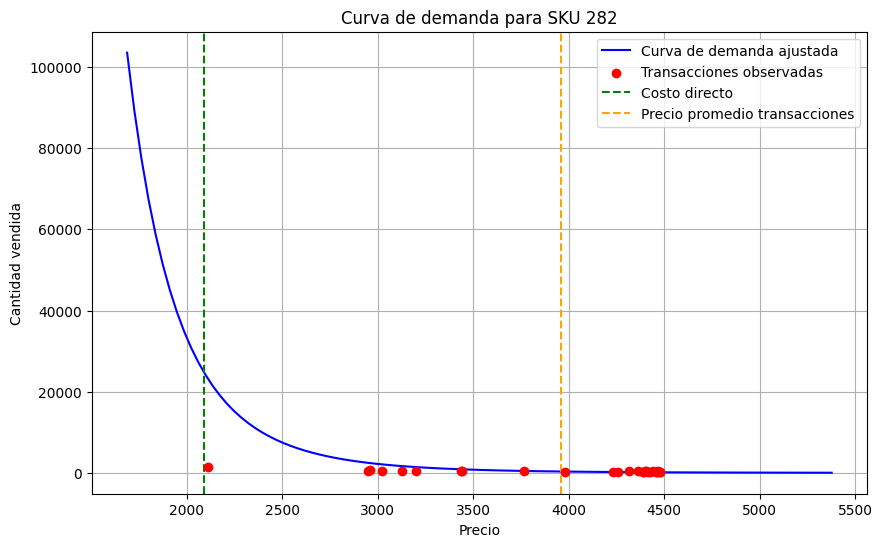

In [30]:
# Graficamos curva de demanda ajustada y puntos de venta
Q_hat = lambda p: A_hat * (p ** epsilon)

plt.figure(figsize=(10, 6))
# Curva de demanda ajustada
plt.plot(p_range, Q_hat(p_range), label="Curva de demanda ajustada", color="blue")
# Puntos de transacciones observadas
plt.scatter(P, Q, color="red", label="Transacciones observadas", zorder=5)
# Linea de Costo directo por kilo
plt.axvline(x=COSTO_DIRECTO_POR_KILO, color="green", linestyle="--", label="Costo directo")
# Linea de precio promedio
plt.axvline(x=P_promedio, color="orange", linestyle="--", label="Precio promedio transacciones")
plt.xlabel("Precio")
plt.ylabel("Cantidad vendida")
plt.title(f"Curva de demanda para SKU {SKU}")
plt.legend()
plt.grid()
plt.show()

In [31]:
margen_contr_total = lambda p: (p - COSTO_DIRECTO_POR_KILO) * Q_hat(p)

precio_optimo = p_range[np.argmax(margen_contr_total(p_range))]
print(f"Precio óptimo sugerido para SKU {SKU}: {precio_optimo:.2f}")

Precio óptimo sugerido para SKU 282: 2470.71


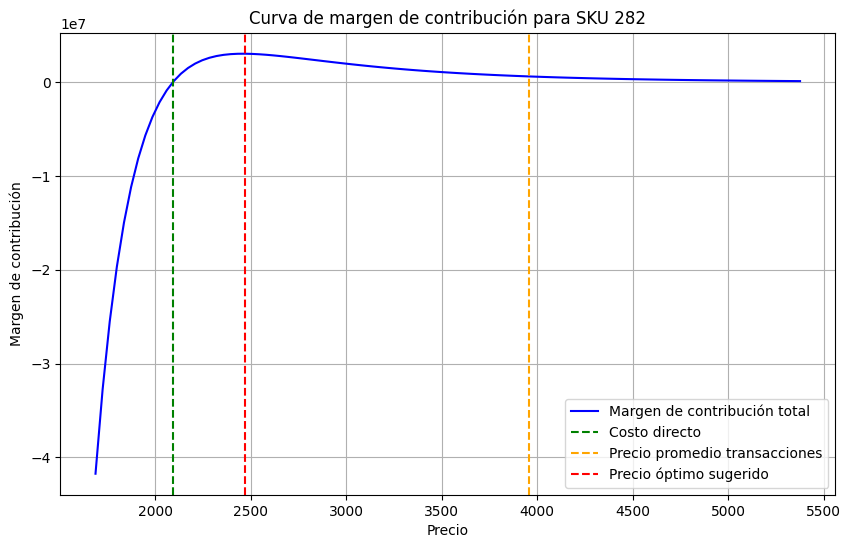

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(p_range, margen_contr_total(p_range), label="Margen de contribución total", color="blue")
plt.axvline(x=COSTO_DIRECTO_POR_KILO, color="green", linestyle="--", label="Costo directo")
plt.axvline(x=P_promedio, color="orange", linestyle="--", label="Precio promedio transacciones")
plt.axvline(x=precio_optimo, color="red", linestyle="--", label="Precio óptimo sugerido")
plt.xlabel("Precio")
plt.ylabel("Margen de contribución")
plt.title(f"Curva de margen de contribución para SKU {SKU}")
plt.legend()
plt.grid()
plt.show()